In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/miadul/irrigation-water-requirement-prediction-dataset/irrigation_prediction.csv
/kaggle/input/competitions/playground-series-s6e4/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e4/train.csv
/kaggle/input/competitions/playground-series-s6e4/test.csv


# Loadings and Configs

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import TargetEncoder
from sklearn.metrics import balanced_accuracy_score
from sklearn.utils.class_weight import compute_sample_weight
from itertools import combinations

import gc
import torch
import warnings
warnings.filterwarnings("ignore")

pd.set_option('display.max_columns', None)

In [3]:
# load
train = pd.read_csv("/kaggle/input/competitions/playground-series-s6e4/train.csv")
test = pd.read_csv("/kaggle/input/competitions/playground-series-s6e4/test.csv")
orig = pd.read_csv("/kaggle/input/datasets/miadul/irrigation-water-requirement-prediction-dataset/irrigation_prediction.csv")

# print shape
print(train.shape)
print(test.shape)
print(orig.shape)

# Configs
target = "Irrigation_Need"

cat_cols = ['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season',
       'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region']

num_cols = ['Soil_pH', 'Soil_Moisture', 'Organic_Carbon',
       'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm',
       'Sunlight_Hours', 'Wind_Speed_kmh', 'Field_Area_hectare',
       'Previous_Irrigation_mm']

base = [col for col in train.columns if col not in ["id",target]]

(630000, 21)
(270000, 20)
(10000, 20)


In [4]:
top_cat_cols = ['Crop_Growth_Stage',  'Mulching_Used', 'Crop_Type']

top_num_cols = ['Soil_Moisture', 'Temperature_C', 'Wind_Speed_kmh', 'Rainfall_mm']

top_cols = ['Soil_Moisture', 'Crop_Growth_Stage', 'Temperature_C', 
            'Mulching_Used', 'Wind_Speed_kmh', 'Rainfall_mm']

In [5]:
# target mapping
target_map = {'Low':0, 'Medium':1, 'High':2}
for df in [train, orig]:
    df[target] = df[target].map(target_map)

# Feature Engineering

In [6]:
train_fe = train.copy()
test_fe = test.copy()
orig_fe = orig.copy()

## formula and domain

In [7]:
def add_threshold_distances(df):
    """Signed distances from key domain thresholds."""
    df["soil_lt_25"]     = (df["Soil_Moisture"] < 25).astype(int)
    df["wind_gt_10"]     = (df["Wind_Speed_kmh"] > 10).astype(int)
    df["temp_gt_30"]     = (df["Temperature_C"] > 30).astype(int)
    df["rain_lt_300"]    = (df["Rainfall_mm"] < 300).astype(int)

    # domain
    df["moist_rain"]     = df["Soil_Moisture"] / (df["Rainfall_mm"] + 1)
    df["moist_temp"]     = df["Soil_Moisture"] / (df["Temperature_C"] + 1)
    df["moist_wind"]    = df["Soil_Moisture"] / (df["Wind_Speed_kmh"] + 1)
    df["ET_proxy"]       = (df["Temperature_C"] * df["Wind_Speed_kmh"] * df["Sunlight_Hours"]) / (df["Humidity"] + 1)
    df["heat_stress"]    = df["Temperature_C"] * df["Sunlight_Hours"]
    df["dfrying_force"]  = df["Wind_Speed_kmh"] * df["Temperature_C"] / (df["Humidity"] + 1)
    df["water_supply"]   = df["Rainfall_mm"] + df["Previous_Irrigation_mm"]
    df["water_dfeficit"] = df["Soil_Moisture"] - df["water_supply"] * 0.1
    df["soil_quality"]   = df["Organic_Carbon"] / (df["Electrical_Conductivity"] + 0.1)
    df["moist_x_temp"]   = df["Soil_Moisture"] * df["Temperature_C"]
    df["windf_x_temp"]   = df["Wind_Speed_kmh"] * df["Temperature_C"]
    
    return df

train_fe = add_threshold_distances(train_fe)
test_fe = add_threshold_distances(test_fe)
orig_fe = add_threshold_distances(orig_fe)


def add_formula_features(df):
    df['high_score'] = (
        (df['Soil_Moisture'] < 25) * 2 + 
        (df['Rainfall_mm'] < 300) * 2 + 
        (df['Temperature_C'] > 30) * 1 + 
        (df['Wind_Speed_kmh'] > 10) * 1
    )
    
    df['low_score'] = (
        (df['Crop_Growth_Stage'].isin(['Harvest', 'Sowing'])) * 2 + 
        (df['Mulching_Used'] == 'Yes') * 1
    )
    
    df['formula_score'] = df['high_score'] - df['low_score']

    df['formula_pred'] = 0 # Low
    df.loc[(df['formula_score'] > 0) & (df['formula_score'] <= 3), 'formula_pred'] = 1 # Medium
    df.loc[df['formula_score'] > 3, 'formula_pred'] = 2 # High
    return df

train_fe = add_formula_features(train_fe)
test_fe = add_formula_features(test_fe)
orig_fe = add_formula_features(orig_fe)

## bigrams

In [8]:
'''
here i take top_cat_cols and it consist only two so only 1 bigram will 
create but you can experiment with all cat cols
'''
BIGRAM_COLS = []
TRIGRAM_COLS = []

TOP4 = top_cat_cols
dataframes = [train_fe, test_fe, orig_fe] # Clean reference

print("\n🚀 Creating N-Gram Features...")

# 1. Bi-grams (Pairs)
for c1, c2 in combinations(top_cat_cols, 2):
    col_name = f"BG_{c1}_{c2}"
    for df in dataframes:
        df[col_name] = df[c1].astype(str) + "_" + df[c2].astype(str)
    BIGRAM_COLS.append(col_name)

# 2. Tri-grams (Triples)
for c1, c2, c3 in combinations(TOP4, 3):
    col_name = f"TG_{c1}_{c2}_{c3}"
    for df in dataframes:
        df[col_name] = df[c1].astype(str) + "_" + df[c2].astype(str) + "_" + df[c3].astype(str)
    TRIGRAM_COLS.append(col_name)

NGRAM_COLS = BIGRAM_COLS + TRIGRAM_COLS
for df in dataframes:
    df[NGRAM_COLS] = df[NGRAM_COLS].astype('category')

print(f"✅ Created {len(NGRAM_COLS)} total N-gram features.")

# factorize
ngram_cols = BIGRAM_COLS + TRIGRAM_COLS

print(f"Factorizing {len(ngram_cols)} N-Gram columns...")

for col in ngram_cols:
    combined = pd.concat([train_fe[col], test_fe[col], orig_fe[col]], axis=0).astype(str)
    
    # Factorize
    labels, uniques = pd.factorize(combined)
    n_train = len(train_fe)
    n_test = len(test_fe)
    
    train_fe[col] = labels[:n_train]
    test_fe[col]  = labels[n_train : n_train + n_test]
    orig_fe[col]  = labels[n_train + n_test :]

print("Factorization complete. All N-Grams are now integers.")


🚀 Creating N-Gram Features...
✅ Created 4 total N-gram features.
Factorizing 4 N-Gram columns...
Factorization complete. All N-Grams are now integers.


## num & cat cols interactions

In [9]:
BIN_CAT_INT_COLS = []
for num_col in top_num_cols:
    bin_col = f"{num_col}_bin"
    train_fe[bin_col], bins = pd.qcut(train_fe[num_col], q=5, labels=False, 
                                           retbins=True, duplicates='drop')
    for df in [test_fe, orig_fe]:
        df[bin_col] = pd.cut(df[num_col], bins=bins, labels=False, 
                             include_lowest=True).fillna(0).astype(int)

    for cat_col in top_cat_cols:
        int_name = f"{num_col}_bin_{cat_col}_int"        
        for df in [train_fe, test_fe, orig_fe]:
            df[int_name] = df[bin_col].astype(str) + "_" + df[cat_col].astype(str)
        BIN_CAT_INT_COLS.append(int_name)

# droping numerical bins
for df in [train_fe, test_fe, orig_fe]:
    df.drop(columns=[f"{num_col}_bin" for num_col in top_num_cols], inplace=True)

print(f"✅ Created {len(BIN_CAT_INT_COLS)} new Binned-Interaction features.")

for col in BIN_CAT_INT_COLS:
    codes, uniques = pd.factorize(train_fe[col])
    train_fe[col] = codes.astype('int')

    mapping = {val: i for i, val in enumerate(uniques)}
    
    test_fe[col] = test_fe[col].map(mapping)
    orig_fe[col] = orig_fe[col].map(mapping)

print(f"✅ Clean Integer Mapping complete (0-indexed). Ready for CuPy.")

✅ Created 12 new Binned-Interaction features.
✅ Clean Integer Mapping complete (0-indexed). Ready for CuPy.


## num cat agg cols

In [10]:
NUM_CAT_AGG_COLS = []

for cat_col in top_cat_cols:
    for num_col in top_num_cols:
        group_means = train_fe.groupby(cat_col)[num_col].mean()

        for df in [train_fe, test_fe, orig_fe]:
            # Group Average
            avg_name = f"{num_col}_avg_by_{cat_col}"
            df[avg_name] = df[cat_col].map(group_means).astype('float')
            
            # Difference
            diff_name = f"{num_col}_diff_{cat_col}"
            df[diff_name] = (df[num_col] - df[avg_name]).astype('float')
            
            # Ratio 
            ratio_name = f"{num_col}_ratio_{cat_col}"
            df[ratio_name] = (df[num_col] / (df[avg_name] + 1e-6)).astype('float')

            NUM_CAT_AGG_COLS.extend([avg_name, diff_name, ratio_name])

# Remove duplicates from the feature list
NUM_CAT_AGG_COLS = list(set(NUM_CAT_AGG_COLS))

print(f"✅ Created {len(top_cat_cols) * len(top_num_cols) * 3} raw numeric interaction columns")

✅ Created 36 raw numeric interaction columns


## rounds, digits, decimals, bins

In [11]:
round_config = {        
     'Soil_Moisture'            : [0,-1],
     'Temperature_C'            : [-1],
     'Rainfall_mm'              : [0,-1,-2,-3],
     'Wind_Speed_kmh'           : [0,-1]
}

digit_config = {        
     'Soil_Moisture'            : [-1,0,1,2],
     'Temperature_C'            : [-1,0,1,2],
     'Rainfall_mm'              : [-3,-2,-1,0,1,2],
     'Wind_Speed_kmh'           : [-1,0,1,2]
}


# ── Rounding Features ─────────────────────────────────────────
# example - 74.25 = 70 ( nearest int rounding)
ROUND = []
for col, r_values in round_config.items():
    for r in r_values:
        feat = f"{col}_r{r}"
        for df in [train_fe, test_fe, orig_fe]:
            df[feat] = df[col].round(r)
        ROUND.append(feat)
print(f"CREATED {len(ROUND)} ROUND FEATURES")

# ── Digit Extraction ──────────────────────────────────────────
# example - 74.25 = 7 , 4 , 2 , 5 (extract four digits from this)
DIGITS = []
for col, k_values in digit_config.items():
    for k in k_values:
        feat = f"{col}_d{k}"
        for df in [train_fe, test_fe, orig_fe]:
            df[feat] = ((df[col] * 10**k) % 10).astype(int)
        DIGITS.append(feat)
print(f"CREATED {len(DIGITS)} DIGITS FEATURES")

# ── Decimal Features ──────────────────────────────────────────
# example - 74.25 = 0.25 
DECIMALS = []
for col in top_num_cols:
    feat = f"{col}_decimal"
    for df in [train_fe, test_fe, orig_fe]:
        df[feat] = (df[col] % 1).round(2)
    DECIMALS.append(feat)
print(f"CREATED {len(DECIMALS)} DECIMALS FEATURES")

# ── BIN Features ──────────────────────────────────────────
BINS = []
for col in top_num_cols:
    feat = f"{col}_bin"
    train_fe[feat], bin_edges = pd.qcut(
        train_fe[col], q=10, labels=False, duplicates='drop', retbins=True
    )
    test_fe[col] = test_fe[col].clip(bin_edges[0], bin_edges[-1])
    test_fe[feat] = pd.cut(
        test_fe[col], bins=bin_edges, labels=False, include_lowest=True
    ).astype(int)

    orig_fe[col] = orig_fe[col].clip(bin_edges[0], bin_edges[-1])
    orig_fe[feat] = pd.cut(
        orig_fe[col], bins=bin_edges, labels=False, include_lowest=True
    ).astype(int)
    BINS.append(feat)
print(f"CREATED {len(BINS)} BINS FEATURES")

CREATED 9 ROUND FEATURES
CREATED 18 DIGITS FEATURES
CREATED 4 DECIMALS FEATURES
CREATED 4 BINS FEATURES


## pairs

In [12]:
PAIRS = []
pair_cols = top_cols

train_len = train_fe.shape[0]
test_len = test_fe.shape[0]
orig_len = orig_fe.shape[0]
combined_len = train_len + test_len + orig_len

for col1, col2 in combinations(pair_cols, 2):
    name = f"{col1}__{col2}"

    # 1. Create temporary string series
    combined_str = pd.concat([
        train_fe[col1].astype(str) + '_' + train_fe[col2].astype(str),
        test_fe[col1].astype(str) + '_' + test_fe[col2].astype(str),
        orig_fe[col1].astype(str) + '_' + orig_fe[col2].astype(str)
    ], ignore_index=True)

    # 2. Factorize
    combined_codes, _ = pd.factorize(combined_str)
    
    # 3. Memory Cleanup
    del combined_str
    gc.collect()

    # 4. Cardinality Filter
    unique_count = len(np.unique(combined_codes))
    if unique_count > (combined_len // 2) or unique_count <= 1:
        del combined_codes
        continue

    # 5. Assign Integer Codes back to DataFrames
    train_fe[name] = combined_codes[:train_len]
    test_fe[name]  = combined_codes[train_len : train_len + test_len]
    orig_fe[name]  = combined_codes[train_len + test_len:]

    PAIRS.append(name)
    
    del combined_codes
    gc.collect()

print(f"{len(PAIRS)} pairwise combinations created.")

9 pairwise combinations created.


# Model

In [13]:
for df in [train_fe, test_fe, orig_fe]:
    for col in cat_cols:
        df[col] = df[col].astype('category')

In [14]:
# making X and y for model training
X_train = train_fe.drop([target, "id"], axis=1)
y_train = train_fe[target]
X_orig = orig_fe.drop(target,axis=1)
y_orig = orig_fe[target]
X_test = test_fe.drop("id", axis=1)

#print shape
print(X_train.shape)
print(y_train.shape)
print(X_orig.shape)
print(y_orig.shape)
print(X_test.shape)

(630000, 134)
(630000,)
(10000, 134)
(10000,)
(270000, 134)


In [15]:
# --- Params ---
RANDOM_STATE = 42
N_SPLITS = 5

params_xgb = {
    'objective': 'multi:softprob',
    'num_class': 3,
    'n_estimators': 2600,      
    'learning_rate': 0.05,
    'max_depth': 3,
    'subsample': 0.9,
    'colsample_bytree':0.8,
    'max_bin':1100, # 1100
    'eval_metric': 'mlogloss',
    'n_jobs': -1,
    'random_state': RANDOM_STATE,
    'device': 'cuda',
    'enable_categorical': True
}

In [16]:
# --- Configuration ---
ORIG_ROW_WEIGHT = 0.5
DROP_COLS = PAIRS + NUM_CAT_AGG_COLS + BIN_CAT_INT_COLS
te_features = X_train.columns.tolist()

# --- SKF ---
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

# --- Training ---
oof_preds_xgb = np.zeros((len(X_train), 3))
test_preds_xgb = np.zeros((len(X_test), 3))
fold_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
    print(f"\n{'='*60}\nFold {fold + 1}/{N_SPLITS}\n{'='*60}")
    
    # 1. Split
    X_tr_real, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr_real, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    # 2. Combine with External Data (X_orig)
    X_tr_combined = pd.concat([X_tr_real, X_orig], axis=0).reset_index(drop=True)
    y_tr_combined = np.concatenate([y_tr_real, y_orig])
    
    # 3. Target Encoding (In-Fold to prevent leakage)
    encoder = TargetEncoder(target_type="multiclass", smooth="auto", cv=5, random_state=RANDOM_STATE)
    
    # Fit on combined training data, transform all
    X_tr_te = encoder.fit_transform(X_tr_combined[te_features], y_tr_combined)
    X_val_te = encoder.transform(X_val[te_features])
    X_test_te = encoder.transform(X_test[te_features])
    
    te_cols = []
    for col in te_features:
        for class_id in range(3): # 0, 1, 2
            te_cols.append(f"TE_{col}_class{class_id}")
                
    X_tr_combined[te_cols] = X_tr_te
    X_val[te_cols] = X_val_te
    X_test_copy = X_test.copy()
    X_test_copy[te_cols] = X_test_te
    
    # 4. Drop unwanted columns
    X_tr_final = X_tr_combined.drop(columns=DROP_COLS)
    X_val_final = X_val.drop(columns=DROP_COLS)
    X_te_final = X_test_copy.drop(columns=DROP_COLS)
    
    # 5. Weights
    sample_weights = compute_sample_weight('balanced', y_tr_combined)
    sample_weights[len(train_idx):] *= ORIG_ROW_WEIGHT
    
    # 6. Fit Model
    model_xgb = XGBClassifier(**params_xgb)
    model_xgb.fit(
        X_tr_final, y_tr_combined,
        eval_set=[(X_val_final, y_val)],
        sample_weight=sample_weights,
        verbose=200
    )
    
    # 7. Predictions
    val_preds_proba = model_xgb.predict_proba(X_val_final)
    oof_preds_xgb[val_idx] = val_preds_proba
    
    test_preds_xgb += model_xgb.predict_proba(X_te_final) / N_SPLITS
    
    # Fold Score
    val_preds = np.argmax(val_preds_proba, axis=1)
    fold_ba = balanced_accuracy_score(y_val, val_preds)
    fold_scores.append(fold_ba)
    print(f"Val Balanced Accuracy: {fold_ba:.4f}")
    
    del model_xgb, X_tr_final, X_val_final, X_te_final
    gc.collect()

# --- Final Results ---
raw_oof_ba = balanced_accuracy_score(y_train, np.argmax(oof_preds_xgb, axis=1))
print(f"\nOOF Balanced Accuracy: {raw_oof_ba:.6f}")


Fold 1/5
[0]	validation_0-mlogloss:1.02976
[200]	validation_0-mlogloss:0.06291
[400]	validation_0-mlogloss:0.05692
[600]	validation_0-mlogloss:0.05452
[800]	validation_0-mlogloss:0.05306
[1000]	validation_0-mlogloss:0.05200
[1200]	validation_0-mlogloss:0.05119
[1400]	validation_0-mlogloss:0.05057
[1600]	validation_0-mlogloss:0.04999
[1800]	validation_0-mlogloss:0.04957
[2000]	validation_0-mlogloss:0.04921
[2200]	validation_0-mlogloss:0.04890
[2400]	validation_0-mlogloss:0.04864
[2599]	validation_0-mlogloss:0.04842
Val Balanced Accuracy: 0.9772

Fold 2/5
[0]	validation_0-mlogloss:1.02981
[200]	validation_0-mlogloss:0.06416
[400]	validation_0-mlogloss:0.05769
[600]	validation_0-mlogloss:0.05508
[800]	validation_0-mlogloss:0.05350
[1000]	validation_0-mlogloss:0.05239
[1200]	validation_0-mlogloss:0.05153
[1400]	validation_0-mlogloss:0.05090
[1600]	validation_0-mlogloss:0.05036
[1800]	validation_0-mlogloss:0.04994
[2000]	validation_0-mlogloss:0.04961
[2200]	validation_0-mlogloss:0.04935
[2

📊 Detailed Classification Report:
              precision    recall  f1-score   support

         Low       0.99      0.99      0.99    369917
      Medium       0.99      0.98      0.98    239074
        High       0.93      0.96      0.95     21009

    accuracy                           0.99    630000
   macro avg       0.97      0.98      0.97    630000
weighted avg       0.99      0.99      0.99    630000



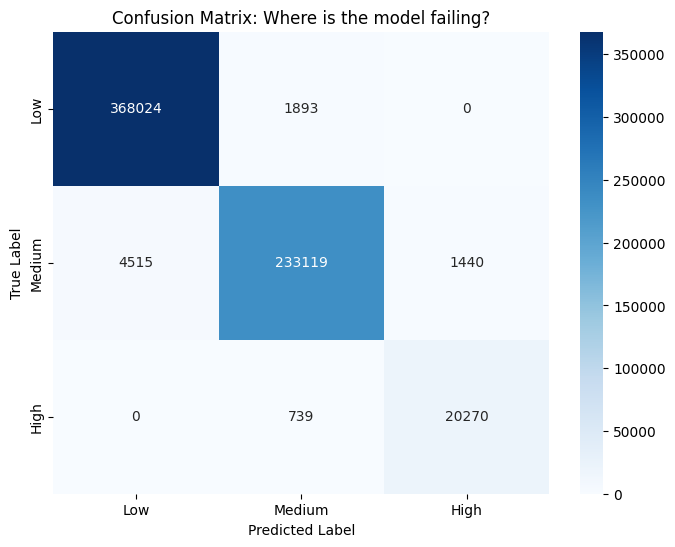

In [17]:
from sklearn.metrics import classification_report, confusion_matrix

# 1. Convert OOF probabilities to hard labels (0, 1, or 2)
final_oof_labels = np.argmax(oof_preds_xgb, axis=1)

# 2. Print the detailed report
# This shows Precision/Recall for EACH class
print("📊 Detailed Classification Report:")
print(classification_report(y_train, final_oof_labels, target_names=['Low', 'Medium', 'High']))

# 3. Create a Confusion Matrix
cm = confusion_matrix(y_train, final_oof_labels)

# 4. Plot it visually to see where the errors are
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Low', 'Medium', 'High'], 
            yticklabels=['Low', 'Medium', 'High'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: Where is the model failing?')
plt.show()

# Bias Tuning- Log-Odds

In [18]:
print("\n🚀 Phase 3: Bias Tuning (Log-Odds Correction)...")

def public_preds(proba, bias):
    return np.argmax(np.log(np.clip(proba, 1e-15, 1.0)) + bias, axis=1)

def tune_bias(proba, y_true):
    best_bias = np.zeros(proba.shape[1], dtype=np.float64)
    best_score = balanced_accuracy_score(y_true, public_preds(proba, best_bias))
    history = [best_score]
    
    for step in (1.0, 0.5, 0.2, 0.1, 0.05, 0.02, 0.01, 0.005, 0.002):
        improved = True
        while improved:
            improved = False
            for ci in range(proba.shape[1]):
                for d in (-1.0, 1.0):
                    c = best_bias.copy()
                    c[ci] += d * step
                    s = balanced_accuracy_score(y_true, public_preds(proba, c))
                    if s > best_score + 1e-9:
                        best_bias, best_score, improved = c, s, True
                        history.append(best_score)
    return best_bias, best_score, history
    
raw_oof_ba = balanced_accuracy_score(y_train, np.argmax(oof_preds_xgb, axis=1))
print(f"📊 Raw OOF Balanced Accuracy: {raw_oof_ba:.6f}")

best_bias, tuned_ba, opt_history = tune_bias(oof_preds_xgb, y_train)
print(f"✨ Found Optimal Biases [Low, Medium, High]: {best_bias}")
print(f"📈 Tuned OOF Balanced Accuracy: {tuned_ba:.6f} (+{tuned_ba - raw_oof_ba:.6f})")


🚀 Phase 3: Bias Tuning (Log-Odds Correction)...
📊 Raw OOF Balanced Accuracy: 0.978266
✨ Found Optimal Biases [Low, Medium, High]: [-1.357 -1.193  0.   ]
📈 Tuned OOF Balanced Accuracy: 0.980162 (+0.001895)


In [19]:
reverse_map = {0: 'Low', 1: 'Medium', 2: 'High'}

final_preds = public_preds(test_preds_xgb, best_bias)
final_labels = [reverse_map[p] for p in final_preds]

submission = pd.DataFrame({
    'id': test['id'],
    'Irrigation_Need': final_labels
})
submission.to_csv('submission.csv', index=False)

print("\n✅ submission.csv generated successfully!")
print("Final Prediction Distribution:")
print(submission.shape)
print(submission['Irrigation_Need'].value_counts(normalize=True) * 100)


✅ submission.csv generated successfully!
Final Prediction Distribution:
(270000, 2)
Irrigation_Need
Low       59.029259
Medium    37.150370
High       3.820370
Name: proportion, dtype: float64


In [20]:
# =========================================================
# Seed42 XGB - Log-odds bias variants
#
# 前提:
#   oof_preds_xgb  : OOF prob, class order [Low, Medium, High]
#   test_preds_xgb : TEST prob, class order [Low, Medium, High]
#   y_train        : labels 0/1/2, [Low, Medium, High]
#   test           : test dataframe with id
# =========================================================

import numpy as np
import pandas as pd
from sklearn.metrics import balanced_accuracy_score, recall_score

TARGET = "Irrigation_Need"

reverse_map = {
    0: "Low",
    1: "Medium",
    2: "High",
}

def pred_with_bias(proba, bias):
    bias = np.asarray(bias, dtype=np.float64)
    return np.argmax(np.log(np.clip(proba, 1e-15, 1.0)) + bias, axis=1)

def make_submission(pred, filename):
    sub = pd.DataFrame({
        "id": test["id"],
        TARGET: pd.Series(pred).map(reverse_map),
    })
    sub.to_csv(filename, index=False)
    return sub

def eval_bias(name, bias, base_test_pred=None):
    oof_pred = pred_with_bias(oof_preds_xgb, bias)
    test_pred = pred_with_bias(test_preds_xgb, bias)

    oof_ba = balanced_accuracy_score(y_train, oof_pred)
    rec = recall_score(
        y_train,
        oof_pred,
        labels=[0, 1, 2],
        average=None,
        zero_division=0,
    )

    filename = f"submission_xgb_seed42_{name}.csv"
    sub = make_submission(test_pred, filename)

    vc = sub[TARGET].value_counts(normalize=True)

    diff_vs_base = None
    if base_test_pred is not None:
        diff_vs_base = int((test_pred != base_test_pred).sum())

    return {
        "name": name,
        "filename": filename,
        "bias_low": bias[0],
        "bias_medium": bias[1],
        "bias_high": bias[2],
        "oof_ba": oof_ba,
        "recall_low": rec[0],
        "recall_medium": rec[1],
        "recall_high": rec[2],
        "sub_low_rate": vc.get("Low", 0.0),
        "sub_medium_rate": vc.get("Medium", 0.0),
        "sub_high_rate": vc.get("High", 0.0),
        "diff_vs_original": diff_vs_base,
    }

# 元ノートのbias
base_bias = np.array([-1.357, -1.193, 0.0], dtype=np.float64)
base_test_pred = pred_with_bias(test_preds_xgb, base_bias)

# =========================================================
# Candidate biases
# class order: [Low, Medium, High]
# =========================================================
bias_candidates = {}

# 0. original
bias_candidates["original"] = base_bias.copy()

# 1. bias全体の強弱
# beta小さい: High圧を弱める
# beta大きい: High圧を強める
for beta in [0.96, 0.98, 0.99, 1.01, 1.02, 1.04]:
    bias_candidates[f"beta_{str(beta).replace('.', 'p')}"] = base_bias * beta

# 2. High圧だけ調整
# Low/Mediumを同時に下げる = Highが増える
# Low/Mediumを同時に上げる = Highが減る
for d in [-0.040, -0.025, -0.015, 0.015, 0.025, 0.040]:
    if d < 0:
        name = f"high_more_{abs(d):.3f}".replace(".", "p")
    else:
        name = f"high_less_{abs(d):.3f}".replace(".", "p")
    bias_candidates[name] = base_bias + np.array([d, d, 0.0])

# 3. Low / Medium 境界だけ調整
# Medium biasを上げる = Mediumが増えやすい
# Medium biasを下げる = Mediumが減りやすい
for d in [-0.040, -0.020, 0.020, 0.040]:
    if d > 0:
        name = f"medium_more_{abs(d):.3f}".replace(".", "p")
    else:
        name = f"medium_less_{abs(d):.3f}".replace(".", "p")
    bias_candidates[name] = base_bias + np.array([0.0, d, 0.0])

# 4. Lowだけ調整
# Low biasを上げる = Lowが増えやすい
# Low biasを下げる = Lowが減りやすい
for d in [-0.030, 0.030]:
    if d > 0:
        name = f"low_more_{abs(d):.3f}".replace(".", "p")
    else:
        name = f"low_less_{abs(d):.3f}".replace(".", "p")
    bias_candidates[name] = base_bias + np.array([d, 0.0, 0.0])

# =========================================================
# Evaluate and save
# =========================================================
rows = []

for name, bias in bias_candidates.items():
    row = eval_bias(name, bias, base_test_pred=base_test_pred)
    rows.append(row)

summary_df = pd.DataFrame(rows)
summary_df = summary_df.sort_values("oof_ba", ascending=False).reset_index(drop=True)
summary_df.to_csv("xgb_seed42_bias_variant_summary.csv", index=False)

display(summary_df)

print("\nSaved submissions:")
for f in summary_df["filename"].tolist():
    print("-", f)

print("\nTop candidates by OOF:")
display(summary_df.head(10))

,name,filename,bias_low,bias_medium,bias_high,oof_ba,recall_low,recall_medium,recall_high,sub_low_rate,sub_medium_rate,sub_high_rate,diff_vs_original
0,original,submission_xgb_seed42_original.csv,-1.35700,-1.19300,0.0,0.980162,0.994439,0.968131,0.977914,0.590293,0.371504,0.038204,0
1,low_more_0p030,submission_xgb_seed42_low_more_0p030.csv,-1.32700,-1.19300,0.0,0.980147,0.994518,0.968010,0.977914,0.590363,0.371433,0.038204,19
2,low_less_0p030,submission_xgb_seed42_low_less_0p030.csv,-1.38700,-1.19300,0.0,0.980141,0.994315,0.968194,0.977914,0.590204,0.371593,0.038204,24
3,beta_1p01,submission_xgb_seed42_beta_1p01.csv,-1.37057,-1.20493,0.0,0.980138,0.994426,0.968027,0.977962,0.590289,0.371474,0.038237,10
4,high_more_0p025,submission_xgb_seed42_high_more_0p025.csv,-1.38200,-1.21800,0.0,0.980137,0.994439,0.967868,0.978105,0.590293,0.371415,0.038293,24
5,high_more_0p015,submission_xgb_seed42_high_more_0p015.csv,-1.37200,-1.20800,0.0,0.980126,0.994439,0.967976,0.977962,0.590293,0.371452,0.038256,14
6,beta_1p02,submission_xgb_seed42_beta_1p02.csv,-1.38414,-1.21686,0.0,0.980124,0.994423,0.967893,0.978057,0.590281,0.371433,0.038285,25
7,beta_0p99,submission_xgb_seed42_beta_0p99.csv,-1.34343,-1.18107,0.0,0.980121,0.994442,0.968244,0.977676,0.590296,0.371552,0.038152,15
8,high_more_0p040,submission_xgb_seed42_high_more_0p040.csv,-1.39700,-1.23300,0.0,0.980120,0.994439,0.967721,0.978200,0.590293,0.371378,0.038330,34
9,high_less_0p015,submission_xgb_seed42_high_less_0p015.csv,-1.34200,-1.17800,0.0,0.980112,0.994439,0.968269,0.977629,0.590293,0.371570,0.038137,18



Saved submissions:
- submission_xgb_seed42_original.csv
- submission_xgb_seed42_low_more_0p030.csv
- submission_xgb_seed42_low_less_0p030.csv
- submission_xgb_seed42_beta_1p01.csv
- submission_xgb_seed42_high_more_0p025.csv
- submission_xgb_seed42_high_more_0p015.csv
- submission_xgb_seed42_beta_1p02.csv
- submission_xgb_seed42_beta_0p99.csv
- submission_xgb_seed42_high_more_0p040.csv
- submission_xgb_seed42_high_less_0p015.csv
- submission_xgb_seed42_medium_less_0p020.csv
- submission_xgb_seed42_beta_1p04.csv
- submission_xgb_seed42_medium_less_0p040.csv
- submission_xgb_seed42_medium_more_0p020.csv
- submission_xgb_seed42_high_less_0p040.csv
- submission_xgb_seed42_high_less_0p025.csv
- submission_xgb_seed42_beta_0p98.csv
- submission_xgb_seed42_medium_more_0p040.csv
- submission_xgb_seed42_beta_0p96.csv

Top candidates by OOF:


,name,filename,bias_low,bias_medium,bias_high,oof_ba,recall_low,recall_medium,recall_high,sub_low_rate,sub_medium_rate,sub_high_rate,diff_vs_original
0,original,submission_xgb_seed42_original.csv,-1.35700,-1.19300,0.0,0.980162,0.994439,0.968131,0.977914,0.590293,0.371504,0.038204,0
1,low_more_0p030,submission_xgb_seed42_low_more_0p030.csv,-1.32700,-1.19300,0.0,0.980147,0.994518,0.968010,0.977914,0.590363,0.371433,0.038204,19
2,low_less_0p030,submission_xgb_seed42_low_less_0p030.csv,-1.38700,-1.19300,0.0,0.980141,0.994315,0.968194,0.977914,0.590204,0.371593,0.038204,24
3,beta_1p01,submission_xgb_seed42_beta_1p01.csv,-1.37057,-1.20493,0.0,0.980138,0.994426,0.968027,0.977962,0.590289,0.371474,0.038237,10
4,high_more_0p025,submission_xgb_seed42_high_more_0p025.csv,-1.38200,-1.21800,0.0,0.980137,0.994439,0.967868,0.978105,0.590293,0.371415,0.038293,24
5,high_more_0p015,submission_xgb_seed42_high_more_0p015.csv,-1.37200,-1.20800,0.0,0.980126,0.994439,0.967976,0.977962,0.590293,0.371452,0.038256,14
6,beta_1p02,submission_xgb_seed42_beta_1p02.csv,-1.38414,-1.21686,0.0,0.980124,0.994423,0.967893,0.978057,0.590281,0.371433,0.038285,25
7,beta_0p99,submission_xgb_seed42_beta_0p99.csv,-1.34343,-1.18107,0.0,0.980121,0.994442,0.968244,0.977676,0.590296,0.371552,0.038152,15
8,high_more_0p040,submission_xgb_seed42_high_more_0p040.csv,-1.39700,-1.23300,0.0,0.980120,0.994439,0.967721,0.978200,0.590293,0.371378,0.038330,34
9,high_less_0p015,submission_xgb_seed42_high_less_0p015.csv,-1.34200,-1.17800,0.0,0.980112,0.994439,0.968269,0.977629,0.590293,0.371570,0.038137,18


In [21]:
# =========================================================
# Save Sudhanshu-style XGB seed42 probs for ensemble
#
# current order:
#   oof_preds_xgb/test_preds_xgb = [Low, Medium, High]
#
# standard ensemble order:
#   [High, Low, Medium]
# =========================================================

import numpy as np
import pandas as pd

ORIG_TO_STD = [2, 0, 1]  # [Low, Medium, High] -> [High, Low, Medium]

# raw probs
oof_std_raw = oof_preds_xgb[:, ORIG_TO_STD].astype(np.float32)
test_std_raw = test_preds_xgb[:, ORIG_TO_STD].astype(np.float32)

# logodds tuned probs
def apply_log_bias_proba(proba, bias):
    z = np.log(np.clip(proba, 1e-15, 1.0)) + np.asarray(bias)
    z = z - z.max(axis=1, keepdims=True)
    p = np.exp(z)
    p = p / p.sum(axis=1, keepdims=True)
    return p

base_bias = np.array([-1.357, -1.193, 0.0], dtype=np.float64)

oof_tuned = apply_log_bias_proba(oof_preds_xgb, base_bias)
test_tuned = apply_log_bias_proba(test_preds_xgb, base_bias)

oof_std_tuned = oof_tuned[:, ORIG_TO_STD].astype(np.float32)
test_std_tuned = test_tuned[:, ORIG_TO_STD].astype(np.float32)

np.save("oof_xgb_sudhanshu_seed42_raw_std.npy", oof_std_raw)
np.save("test_xgb_sudhanshu_seed42_raw_std.npy", test_std_raw)

np.save("oof_xgb_sudhanshu_seed42_logodds_std.npy", oof_std_tuned)
np.save("test_xgb_sudhanshu_seed42_logodds_std.npy", test_std_tuned)

print("Saved:")
print("- oof_xgb_sudhanshu_seed42_raw_std.npy")
print("- test_xgb_sudhanshu_seed42_raw_std.npy")
print("- oof_xgb_sudhanshu_seed42_logodds_std.npy")
print("- test_xgb_sudhanshu_seed42_logodds_std.npy")

print("\nShapes:")
print("oof raw/std    :", oof_std_raw.shape)
print("test raw/std   :", test_std_raw.shape)
print("oof tuned/std  :", oof_std_tuned.shape)
print("test tuned/std :", test_std_tuned.shape)

Saved:
- oof_xgb_sudhanshu_seed42_raw_std.npy
- test_xgb_sudhanshu_seed42_raw_std.npy
- oof_xgb_sudhanshu_seed42_logodds_std.npy
- test_xgb_sudhanshu_seed42_logodds_std.npy

Shapes:
oof raw/std    : (630000, 3)
test raw/std   : (270000, 3)
oof tuned/std  : (630000, 3)
test tuned/std : (270000, 3)


In [22]:
# =========================================================
# Save npy for xgb_seed42_low_more_0p030
#
# current order:
#   oof_preds_xgb / test_preds_xgb = [Low, Medium, High]
#
# standard ensemble order:
#   [High, Low, Medium]
# =========================================================

import numpy as np
import pandas as pd
from sklearn.metrics import balanced_accuracy_score, recall_score

TARGET = "Irrigation_Need"

# low_more_0p030
# original bias [-1.357, -1.193, 0.0] + [0.030, 0.0, 0.0]
bias_low_more_0030 = np.array([-1.327, -1.193, 0.0], dtype=np.float64)

# original order [Low, Medium, High] -> standard [High, Low, Medium]
ORIG_TO_STD = [2, 0, 1]

reverse_map_original = {
    0: "Low",
    1: "Medium",
    2: "High",
}

def apply_log_bias_proba(proba, bias):
    z = np.log(np.clip(proba, 1e-15, 1.0)) + np.asarray(bias)
    z = z - z.max(axis=1, keepdims=True)
    p = np.exp(z)
    p = p / p.sum(axis=1, keepdims=True)
    return p

# biased probabilities in original order [Low, Medium, High]
oof_low_more_0030_original = apply_log_bias_proba(oof_preds_xgb, bias_low_more_0030)
test_low_more_0030_original = apply_log_bias_proba(test_preds_xgb, bias_low_more_0030)

# standard order [High, Low, Medium]
oof_low_more_0030_std = oof_low_more_0030_original[:, ORIG_TO_STD].astype(np.float32)
test_low_more_0030_std = test_low_more_0030_original[:, ORIG_TO_STD].astype(np.float32)

# save npy
np.save("oof_xgb_sudhanshu_seed42_low_more_0p030_std_0.98111.npy", oof_low_more_0030_std)
np.save("test_xgb_sudhanshu_seed42_low_more_0p030_std_0.98111.npy", test_low_more_0030_std)

# 念のため submission も再保存
test_pred = test_low_more_0030_original.argmax(axis=1)
submission = pd.DataFrame({
    "id": test["id"],
    TARGET: pd.Series(test_pred).map(reverse_map_original),
})
submission.to_csv("submission_xgb_sudhanshu_seed42_low_more_0p030_0.98111.csv", index=False)

# OOF check
oof_pred = oof_low_more_0030_original.argmax(axis=1)
oof_ba = balanced_accuracy_score(y_train, oof_pred)
rec = recall_score(
    y_train,
    oof_pred,
    labels=[0, 1, 2],
    average=None,
    zero_division=0,
)

print("Saved:")
print("- oof_xgb_sudhanshu_seed42_low_more_0p030_std_0.98111.npy")
print("- test_xgb_sudhanshu_seed42_low_more_0p030_std_0.98111.npy")
print("- submission_xgb_sudhanshu_seed42_low_more_0p030_0.98111.csv")

print("\nShapes:")
print("OOF :", oof_low_more_0030_std.shape)
print("TEST:", test_low_more_0030_std.shape)

print("\nOOF BA:", oof_ba)
print("recalls [Low, Medium, High]:", rec)

print("\nSubmission distribution:")
print(submission[TARGET].value_counts(normalize=True).sort_index())
print(submission.head())

Saved:
- oof_xgb_sudhanshu_seed42_low_more_0p030_std_0.98111.npy
- test_xgb_sudhanshu_seed42_low_more_0p030_std_0.98111.npy
- submission_xgb_sudhanshu_seed42_low_more_0p030_0.98111.csv

Shapes:
OOF : (630000, 3)
TEST: (270000, 3)

OOF BA: 0.9801472737407281
recalls [Low, Medium, High]: [0.99451769 0.9680099  0.97791423]

Submission distribution:
Irrigation_Need
High      0.038204
Low       0.590363
Medium    0.371433
Name: proportion, dtype: float64
       id Irrigation_Need
0  630000             Low
1  630001             Low
2  630002             Low
3  630003             Low
4  630004             Low
